In [3]:
import pandas as pd

df = pd.read_csv("umap_all_methods_results_with_fno_metrics.csv")

In [8]:
import re
from collections import defaultdict

columns = df.columns

groups = defaultdict(dict)

pattern = re.compile(r"(.+?)_([xyz])_(\d+d)")

for col in columns:
    m = pattern.match(col)
    if m:
        prefix, coord, dim = m.groups()
        key_str = f"{prefix}_{dim}"
        key_tuple = tuple(key_str.split("_"))
        if key_tuple not in groups:
            groups[key_tuple] = {}
        groups[key_tuple][coord] = col

# 转成 tuple 形式
result = {}
for key_tuple, coords in groups.items():
    if 'z' in coords:  # 3d
        result[key_tuple] = (coords['x'], coords['y'], coords['z'])
    else:             # 2d
        result[key_tuple] = (coords['x'], coords['y'])
        
result_2d = len({key:val for key,val in result.items() if "2d" in key})
result_3d = len({key:val for key,val in result.items() if "3d" in key})

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# 假设 df 和 result 已经准备好了
# 你指定的参数：
selected_key = ('time', 'pca', '2d')   # 你想画哪个
color_col = 'fno_rmse'                 # 哪一列作为 color gradient

# 取出列名
cols = result[selected_key]
dim = len(cols)

# 用 data_type 列分组
shapes = ['o', '^', 's', 'D', 'x', '*', 'P', 'v']
data_types = df['data_type'].unique()
shape_map = {dt: shapes[i % len(shapes)] for i, dt in enumerate(data_types)}

# 画图
fig = plt.figure(figsize=(8, 6))
if dim == 2:
    ax = fig.add_subplot(111)
else:
    ax = fig.add_subplot(111, projection='3d')

for dt in data_types:
    sub_df = df[df['data_type'] == dt]
    if dim == 2:
        sc = ax.scatter(
            sub_df[cols[0]], sub_df[cols[1]],
            c=sub_df[color_col], cmap='viridis',
            marker=shape_map[dt], label=dt, edgecolor='k', alpha=0.7
        )
    else:
        sc = ax.scatter(
            sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
            c=sub_df[color_col], cmap='viridis',
            marker=shape_map[dt], label=dt, edgecolor='k', alpha=0.7
        )

if dim == 2:
    ax.set_xlabel(cols[0])
    ax.set_ylabel(cols[1])
else:
    ax.set_xlabel(cols[0])
    ax.set_ylabel(cols[1])
    ax.set_zlabel(cols[2])

plt.title(f"Scatter plot for {'_'.join(selected_key)}")
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(color_col)

ax.legend(title='data_type')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

def plot_all_scatter(df, result, dim_type='2d', color_col='fno_rmse'):
    """
    按照 2d 或 3d 分类，把 result 里每个 key 对应的 scatter plot 全画出来，
    但只画原来 3x3 网格中的前两行前两列 (4 个子图)。
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    shapes = ['o', '^', 's', 'D', 'x', '*', 'P', 'v']
    data_types = df['data_type'].unique()
    shape_map = {dt: shapes[i % len(shapes)] for i, dt in enumerate(data_types)}

    # 固定 3x3 网格，但只画 (0,0)(0,1)(1,0)(1,1)
    nrows, ncols = 3, 3
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    # 需要的 subplot 索引（按 add_subplot 的顺序）
    wanted_positions = [1, 2, 4, 5]  # 对应 (0,0)(0,1)(1,0)(1,1)

    sc = None
    last_ax = None
    for idx, (key, pos) in enumerate(zip(keys, wanted_positions)):
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, pos, projection='3d' if dim == 3 else None)
        last_ax = ax

        for dt in data_types:
            sub_df = df[df['data_type'] == dt]
            if dim == 2:
                sc = ax.scatter(
                    sub_df[cols[0]], sub_df[cols[1]],
                    c=sub_df[color_col], cmap='viridis',
                    marker=shape_map[dt], label=dt, alpha=0.01, s=40
                )
            else:
                sc = ax.scatter(
                    sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                    c=sub_df[color_col], cmap='viridis',
                    marker=shape_map[dt], label=dt, alpha=0.05, s=40
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])

        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # 统一 colorbar
    if sc is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        plt.sca(fig.axes[0])
        cbar = plt.colorbar(sc, cax=cbar_ax)
        cbar.set_label(color_col)

    # 图例
    if last_ax is not None:
        handles, labels = last_ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        fig.legend(list(uniq.values()), list(uniq.keys()),
                   loc='upper right', title='data_type')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


In [5]:
plot_all_scatter(df, result, dim_type='2d', color_col='fno_rmse', max_per_fig=9)

NameError: name 'result' is not defined

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

def plot_all_scatter_by_data_type(df, result, dim_type='2d', max_per_fig=9, point_size=40):
    """
    按照 2d 或 3d 分类，把 result 里每个 key 对应的 scatter plot 全画出来，放在 3x3 网格里。
    颜色根据 data_type 列的类别区分（categorical），不使用不同点形状。

    Args:
        df: pandas.DataFrame
        result: dict，key 是 tuple，value 是列名列表
        dim_type: '2d' 或 '3d'
        max_per_fig: 每个大图最多画多少个（默认9）
        point_size: 点大小
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    data_types = df['data_type'].unique()
    # 给每个 data_type 分配颜色，使用 tab10 色板循环
    cmap = plt.cm.get_cmap('tab10', len(data_types))
    data_type_color_map = {dt: cmap(i) for i, dt in enumerate(data_types)}

    # 分批次画
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start+max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(ncols*6.4, nrows*6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            ax = fig.add_subplot(nrows, ncols, idx+1, projection='3d' if dim == 3 else None)

            for dt in data_types:
                sub_df = df[df['data_type'] == dt]
                color = data_type_color_map[dt]

                if dim == 2:
                    sc = ax.scatter(
                        sub_df[cols[0]], sub_df[cols[1]],
                        color=color,
                        label=dt, alpha=0.1, s=point_size
                    )
                else:
                    sc = ax.scatter(
                        sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                        color=color,
                        label=dt, alpha=0.1, s=point_size
                    )

            ax.set_xlabel(cols[0])
            ax.set_ylabel(cols[1])
            if dim == 3:
                ax.set_zlabel(cols[2])

            ax.set_title(f"{'_'.join(key)}", fontsize=10)

        # 统一图例
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', title='data_type')

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

/tmp/ipykernel_2446524/550198445.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(data_types))


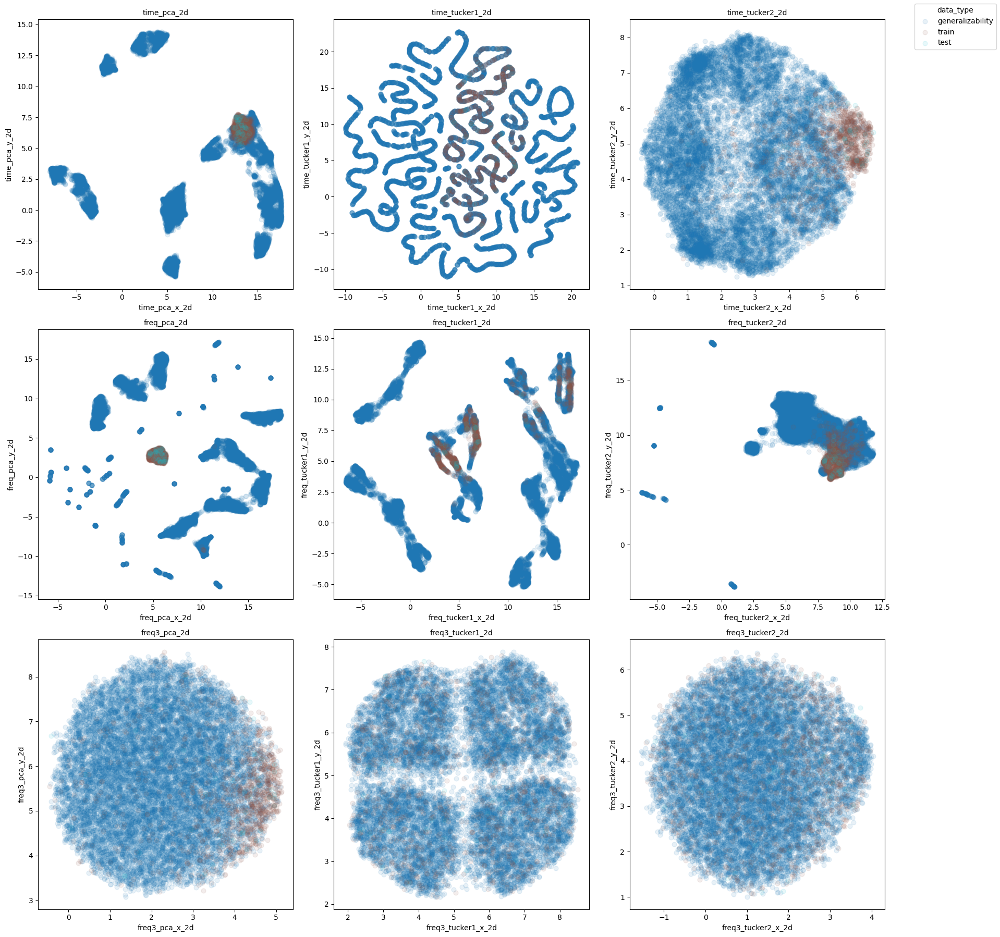

In [51]:
plot_all_scatter_by_data_type(df, result, dim_type='2d', max_per_fig=9, point_size=40)

In [44]:
import matplotlib.pyplot as plt

def plot_all_scatter_by_vrange(df, result, dim_type='2d', max_per_fig=9, point_size=40):
    """
    按 dim_type 选 key，针对 data_type='generalizability' 的数据行画散点图，
    color 根据 (vmax, vmin) 分类（categorical）。

    Args:
        df: pandas.DataFrame
        result: dict，key 是 tuple，value 是列名列表
        dim_type: '2d' 或 '3d'
        max_per_fig: 每个大图最多画多少个（默认9）
        point_size: 点大小
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 只筛选 data_type='generalizability' 的数据
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config 列的字符串为 dict，并生成 (vmax, vmin) tuple 作为分类依据
    import ast
    def parse_vrange(s):
        d = ast.literal_eval(s)
        return (d.get('vmax'), d.get('vmin'))

    df_sub['vrange'] = df_sub['grf_config'].map(parse_vrange)

    vranges = sorted(df_sub['vrange'].unique())
    # 给每个 vrange 分配颜色
    cmap = plt.cm.get_cmap('tab20', len(vranges))
    vrange_color_map = {vr: cmap(i) for i, vr in enumerate(vranges)}

    # 分批次画
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start+max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(ncols*6.4, nrows*6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            ax = fig.add_subplot(nrows, ncols, idx+1, projection='3d' if dim == 3 else None)

            # 按 vrange 分类画点
            for vr in vranges:
                sub_df_vr = df_sub[df_sub['vrange'] == vr]
                if dim == 2:
                    sc = ax.scatter(
                        sub_df_vr[cols[0]], sub_df_vr[cols[1]],
                        color=vrange_color_map[vr],
                        label=f'vmax={vr[0]}, vmin={vr[1]}',
                        alpha=0.05, s=point_size
                    )
                else:
                    sc = ax.scatter(
                        sub_df_vr[cols[0]], sub_df_vr[cols[1]], sub_df_vr[cols[2]],
                        color=vrange_color_map[vr],
                        label=f'vmax={vr[0]}, vmin={vr[1]}',
                        alpha=0.05, s=point_size
                    )

            ax.set_xlabel(cols[0])
            ax.set_ylabel(cols[1])
            if dim == 3:
                ax.set_zlabel(cols[2])

            ax.set_title(f"{'_'.join(key)}", fontsize=10)

            # 图例太多可以考虑用 handles + labels 统一一次画
            # 这里每个subplot都画legend，可能重叠，之后统一画更好

        # 统一图例（所有 vrange）
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', title='(vmax, vmin)')

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

/tmp/ipykernel_2446524/7818230.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(vranges))


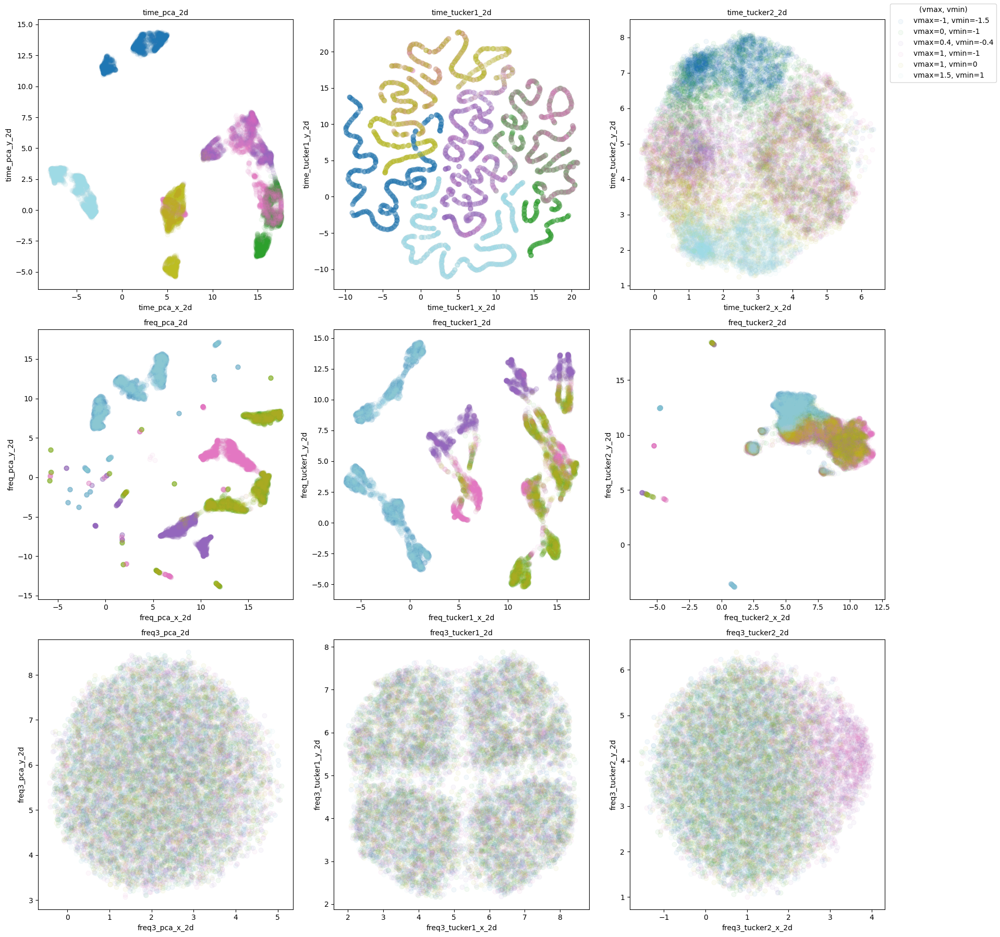

In [45]:
plot_all_scatter_by_vrange(df, result, dim_type='2d', max_per_fig=9, point_size=40)

In [56]:
import matplotlib.pyplot as plt
import ast

def plot_all_scatter_by_kernel(df, result, dim_type='2d', max_per_fig=9, point_size=40):
    """
    按 dim_type 选 key，针对 data_type='generalizability' 的数据行画散点图，
    color 根据 grf_config 里的 kernel 类型分类（categorical）。

    Args:
        df: pandas.DataFrame
        result: dict，key 是 tuple，value 是列名列表
        dim_type: '2d' 或 '3d'
        max_per_fig: 每个大图最多画多少个（默认9）
        point_size: 点大小
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 只筛选 data_type='generalizability' 的数据
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config，提取 kernel 类型
    def parse_kernel(s):
        d = ast.literal_eval(s)
        return d.get('kernel', 'unknown')

    df_sub['kernel'] = df_sub['grf_config'].map(parse_kernel)

    kernels = sorted(df_sub['kernel'].unique())
    cmap = plt.cm.get_cmap('tab10', len(kernels))
    kernel_color_map = {k: cmap(i) for i, k in enumerate(kernels)}

    # 分批次画
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start+max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(ncols*6.4, nrows*6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            ax = fig.add_subplot(nrows, ncols, idx+1, projection='3d' if dim == 3 else None)

            # 按 kernel 分类画点
            for k in kernels:
                sub_df_k = df_sub[df_sub['kernel'] == k]
                if dim == 2:
                    sc = ax.scatter(
                        sub_df_k[cols[0]], sub_df_k[cols[1]],
                        color=kernel_color_map[k],
                        label=f'kernel={k}',
                        alpha=0.05, s=point_size
                    )
                else:
                    sc = ax.scatter(
                        sub_df_k[cols[0]], sub_df_k[cols[1]], sub_df_k[cols[2]],
                        color=kernel_color_map[k],
                        label=f'kernel={k}',
                        alpha=0.05, s=point_size
                    )

            ax.set_xlabel(cols[0])
            ax.set_ylabel(cols[1])
            if dim == 3:
                ax.set_zlabel(cols[2])

            ax.set_title(f"{'_'.join(key)}", fontsize=10)

        # 统一图例
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', title='Kernel Type')

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

/tmp/ipykernel_2446524/1464029778.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(kernels))


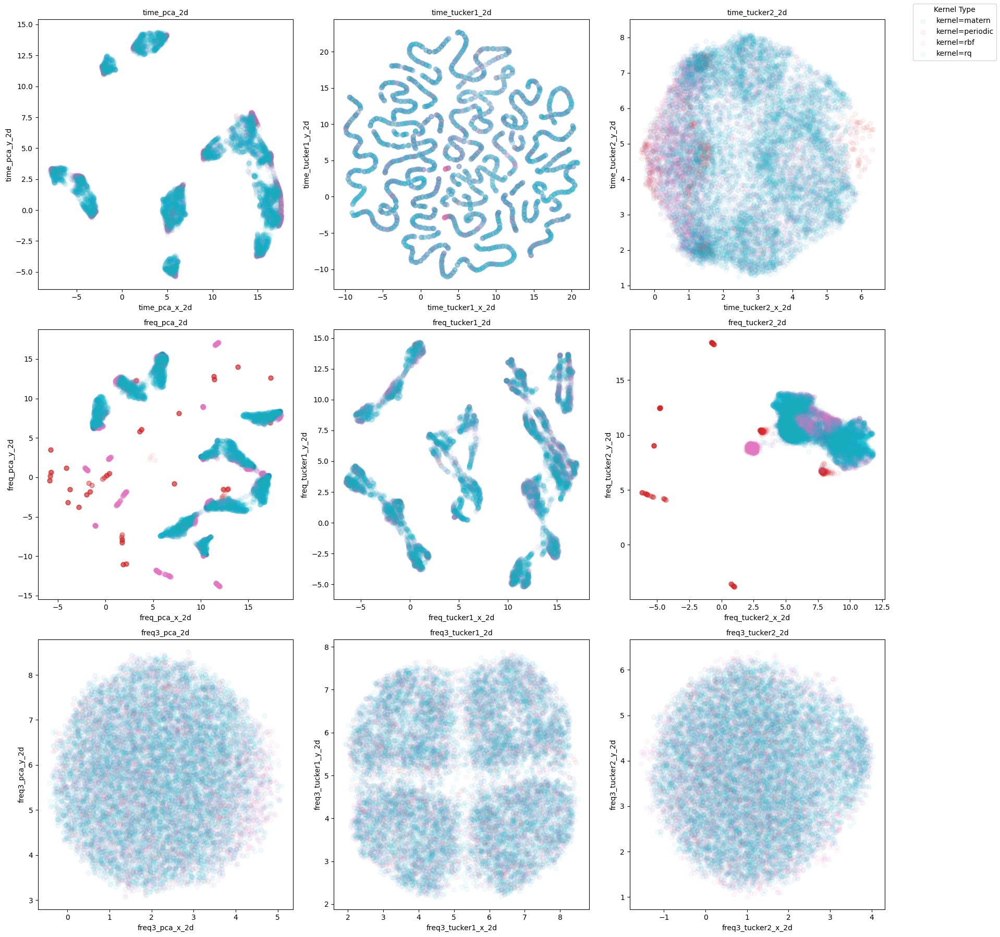

In [57]:
plot_all_scatter_by_kernel(df, result, dim_type='2d', max_per_fig=9, point_size=40)

In [58]:
import matplotlib.pyplot as plt
import ast

def plot_all_scatter_by_grftype(df, result, dim_type='2d', max_per_fig=9, point_size=40):
    """
    按 dim_type 选 key，针对 data_type='generalizability' 的数据行画散点图，
    color 根据 grf_config 里的 grf_type 类型分类（categorical）。

    Args:
        df: pandas.DataFrame
        result: dict，key 是 tuple，value 是列名列表
        dim_type: '2d' 或 '3d'
        max_per_fig: 每个大图最多画多少个（默认9）
        point_size: 点大小
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 只筛选 data_type='generalizability' 的数据
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config，提取 grf_type
    def parse_grftype(s):
        d = ast.literal_eval(s)
        return d.get('grf_type', 'unknown')

    df_sub['grf_type'] = df_sub['grf_config'].map(parse_grftype)

    grf_types = sorted(df_sub['grf_type'].unique())
    cmap = plt.cm.get_cmap('tab10', len(grf_types))
    grf_type_color_map = {gt: cmap(i) for i, gt in enumerate(grf_types)}

    # 分批次画
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start+max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 3
        fig = plt.figure(figsize=(ncols*6.4, nrows*6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            ax = fig.add_subplot(nrows, ncols, idx+1, projection='3d' if dim == 3 else None)

            # 按 grf_type 分类画点
            for gt in grf_types:
                sub_df_gt = df_sub[df_sub['grf_type'] == gt]
                if dim == 2:
                    sc = ax.scatter(
                        sub_df_gt[cols[0]], sub_df_gt[cols[1]],
                        color=grf_type_color_map[gt],
                        label=f'grf_type={gt}',
                        alpha=0.05, s=point_size
                    )
                else:
                    sc = ax.scatter(
                        sub_df_gt[cols[0]], sub_df_gt[cols[1]], sub_df_gt[cols[2]],
                        color=grf_type_color_map[gt],
                        label=f'grf_type={gt}',
                        alpha=0.05, s=point_size
                    )

            ax.set_xlabel(cols[0])
            ax.set_ylabel(cols[1])
            if dim == 3:
                ax.set_zlabel(cols[2])

            ax.set_title(f"{'_'.join(key)}", fontsize=10)

        # 统一图例
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', title='GRF Type')

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

/tmp/ipykernel_2446524/2875819848.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(grf_types))


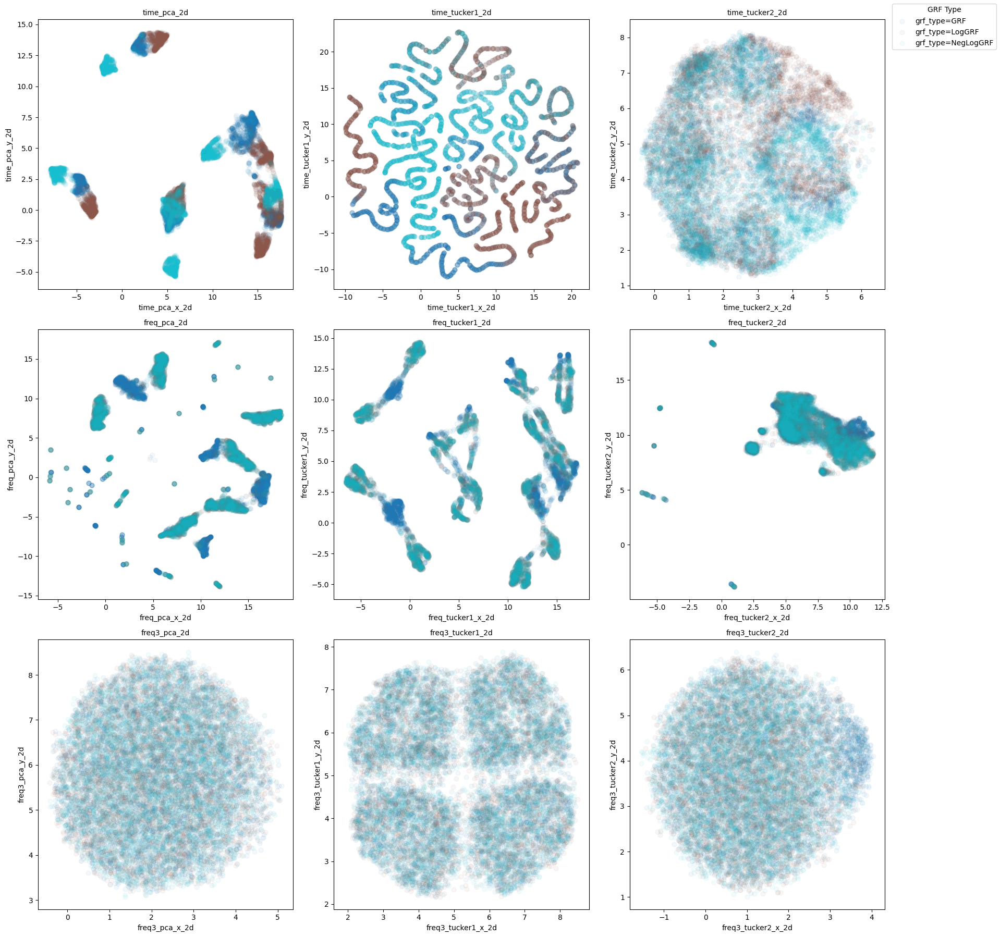

In [59]:
plot_all_scatter_by_grftype(df, result, dim_type='2d', max_per_fig=9, point_size=40)

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import matplotlib.lines as mlines

def plot_all_scatter_with_categorical(df, result, dim_type='2d', color_col='fno_rmse', max_per_fig=9, point_size=20):
    """
    For each key in `result` of given `dim_type`, plot two side-by-side scatter plots:
      - left: color by `color_col` (continuous)
      - right: color by `data_type` (categorical)
    Arrange in a grid with doubled columns.
    """
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ No keys found for {dim_type}.")
        return

    shapes = ['o', '^', 's', 'D', 'x', '*', 'P', 'v']
    data_types = df['data_type'].unique()
    shape_map = {dt: shapes[i % len(shapes)] for i, dt in enumerate(data_types)}
    color_map = {dt: plt.cm.tab10(i % 10) for i, dt in enumerate(data_types)}

    # batch loop
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start + max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 6  # doubled columns
        fig = plt.figure(figsize=(ncols * 6.5, nrows * 6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            # left: continuous color
            ax1 = fig.add_subplot(nrows, ncols, idx * 2 + 1, projection='3d' if dim == 3 else None)
            # right: categorical color
            ax2 = fig.add_subplot(nrows, ncols, idx * 2 + 2, projection='3d' if dim == 3 else None)

            for dt in data_types:
                sub_df = df[df['data_type'] == dt]

                kwargs_common = dict(
                    marker=shape_map[dt], label=dt, alpha=0.1, s=point_size
                )

                # left: color_col (continuous)
                if dim == 2:
                    sc1 = ax1.scatter(
                        sub_df[cols[0]], sub_df[cols[1]],
                        c=sub_df[color_col], cmap='viridis', **kwargs_common
                    )
                else:
                    sc1 = ax1.scatter(
                        sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                        c=sub_df[color_col], cmap='viridis', **kwargs_common
                    )

                # right: data_type (categorical)
                if dim == 2:
                    ax2.scatter(
                        sub_df[cols[0]], sub_df[cols[1]],
                        color=color_map[dt], **kwargs_common
                    )
                else:
                    ax2.scatter(
                        sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                        color=color_map[dt], **kwargs_common
                    )

            # axes labels & titles
            for ax in [ax1, ax2]:
                ax.set_xlabel(cols[0])
                ax.set_ylabel(cols[1])
                if dim == 3:
                    ax.set_zlabel(cols[2])

            ax1.set_title(f"{'_'.join(key)}\ncolor: {color_col}", fontsize=8)
            ax2.set_title(f"{'_'.join(key)}\ncolor: data_type", fontsize=8)

        # 画完所有子图后，构造 categorical legend 的 handles 和 labels
        handles = []
        labels = []
        for dt in data_types:
            handle = mlines.Line2D([], [], color=color_map[dt], marker=shape_map[dt], linestyle='None', markersize=8, label=dt)
            handles.append(handle)
            labels.append(dt)

        # colorbar (for continuous)
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        plt.sca(fig.axes[0])
        cbar = plt.colorbar(sc1, cax=cbar_ax)
        cbar.set_label(color_col)

        # 分类图例放右上角外面一点
        fig.legend(handles, labels, loc='upper right', title='data_type', bbox_to_anchor=(1.1, 1))

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

/tmp/ipykernel_2446524/2038107263.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


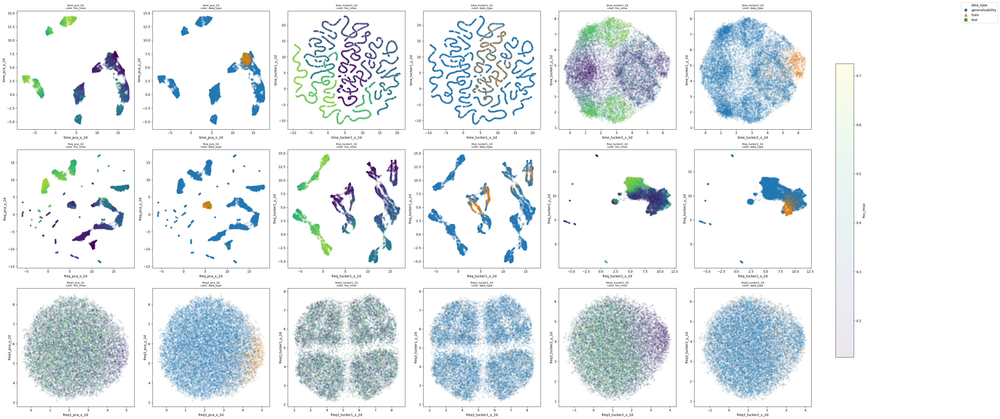

In [35]:
plot_all_scatter_with_categorical(df, result, dim_type='2d', color_col='fno_rmse', max_per_fig=9)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import matplotlib.lines as mlines

def plot_all_scatter_with_categorical(df, result, dim_type='2d', color_col='fno_rmse', max_per_fig=9, point_size=20):
    """
    For each key in `result` of given `dim_type`, plot two side-by-side scatter plots:
      - left: color by `color_col` (continuous)
      - right: color by `data_type` (categorical)
    Arrange in a grid with doubled columns.
    """
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ No keys found for {dim_type}.")
        return

    shapes = ['o', '^', 's', 'D', 'x', '*', 'P', 'v']
    data_types = df['data_type'].unique()
    shape_map = {dt: shapes[i % len(shapes)] for i, dt in enumerate(data_types)}
    color_map = {dt: plt.cm.tab10(i % 10) for i, dt in enumerate(data_types)}

    # batch loop
    for batch_start in range(0, len(keys), max_per_fig):
        batch_keys = keys[batch_start:batch_start + max_per_fig]
        n_plots = len(batch_keys)

        nrows, ncols = 3, 6  # doubled columns
        fig = plt.figure(figsize=(ncols * 6.5, nrows * 6))

        for idx, key in enumerate(batch_keys):
            cols = result[key]
            dim = len(cols)

            # left: continuous color
            ax1 = fig.add_subplot(nrows, ncols, idx * 2 + 1, projection='3d' if dim == 3 else None)
            # right: categorical color
            ax2 = fig.add_subplot(nrows, ncols, idx * 2 + 2, projection='3d' if dim == 3 else None)

            for dt in data_types:
                sub_df = df[df['data_type'] == dt]

                kwargs_common = dict(
                    marker=shape_map[dt], label=dt, alpha=0.1, s=point_size
                )

                # left: color_col (continuous)
                if dim == 2:
                    sc1 = ax1.scatter(
                        sub_df[cols[0]], sub_df[cols[1]],
                        c=sub_df[color_col], cmap='viridis', **kwargs_common
                    )
                else:
                    sc1 = ax1.scatter(
                        sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                        c=sub_df[color_col], cmap='viridis', **kwargs_common
                    )

                # right: data_type (categorical)
                if dim == 2:
                    ax2.scatter(
                        sub_df[cols[0]], sub_df[cols[1]],
                        color=color_map[dt], **kwargs_common
                    )
                else:
                    ax2.scatter(
                        sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                        color=color_map[dt], **kwargs_common
                    )

            # axes labels & titles
            for ax in [ax1, ax2]:
                ax.set_xlabel(cols[0])
                ax.set_ylabel(cols[1])
                if dim == 3:
                    ax.set_zlabel(cols[2])

            ax1.set_title(f"{'_'.join(key)}\ncolor: {color_col}", fontsize=8)
            ax2.set_title(f"{'_'.join(key)}\ncolor: data_type", fontsize=8)

        # 画完所有子图后，构造 categorical legend 的 handles 和 labels
        handles = []
        labels = []
        for dt in data_types:
            handle = mlines.Line2D([], [], color=color_map[dt], marker=shape_map[dt], linestyle='None', markersize=8, label=dt)
            handles.append(handle)
            labels.append(dt)

        # colorbar (for continuous)
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        plt.sca(fig.axes[0])
        cbar = plt.colorbar(sc1, cax=cbar_ax)
        cbar.set_label(color_col)

        # 分类图例放右上角外面一点
        fig.legend(handles, labels, loc='upper right', title='data_type', bbox_to_anchor=(1.1, 1))

        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()

In [39]:
df

,nu_ns,tfinal,nsamples,batch_idx,start_idx,end_idx,times,grf_config,data_type,time_pca_x_2d,...,freq3_tucker1_y_3d,freq3_tucker1_z_3d,freq3_tucker2_x_2d,freq3_tucker2_y_2d,freq3_tucker2_x_3d,freq3_tucker2_y_3d,freq3_tucker2_z_3d,fno_rmse,fno_mae,fno_mape
0,0.00001,20,10,0.0,0.0,10.0,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params...",generalizability,16.088310,...,3.912927,5.865756,0.937430,4.330362,0.439661,4.357585,3.903086,0.748859,0.676504,234.073210
1,0.00001,20,10,0.0,0.0,10.0,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params...",generalizability,15.983200,...,3.474499,4.427947,0.140822,4.271385,-0.587912,3.763178,3.522168,0.859249,0.716817,572.055912
2,0.00001,20,10,0.0,0.0,10.0,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params...",generalizability,16.193913,...,6.620503,5.472033,0.281475,4.621450,-1.139187,4.020286,3.634324,0.744119,0.677654,383.331418
3,0.00001,20,10,0.0,0.0,10.0,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params...",generalizability,14.874703,...,4.243442,6.233158,0.478461,4.731188,0.449129,3.940568,3.853513,0.889847,0.727930,255.978394
4,0.00001,20,10,0.0,0.0,10.0,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params...",generalizability,15.562257,...,4.046930,6.313670,-0.087642,3.178432,0.283547,2.970951,4.111396,0.970804,0.785942,274.652100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,0.00001,20,50,NaN,NaN,NaN,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,NaN,test,12.750979,...,3.396102,4.874950,0.699944,1.525673,-1.000300,2.846733,5.501755,0.332031,0.217225,78.117025
15596,0.00001,20,50,NaN,NaN,NaN,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,NaN,test,12.552012,...,6.447063,5.654722,1.984927,1.354801,-0.511383,2.701592,3.568589,0.554804,0.341593,96.314305
15597,0.00001,20,50,NaN,NaN,NaN,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,NaN,test,12.804382,...,4.596404,4.278989,1.660347,3.829269,-1.224437,4.738020,4.989958,0.339527,0.236643,136.605453
15598,0.00001,20,50,NaN,NaN,NaN,[ 0. 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 1...,NaN,test,13.163679,...,5.614395,4.210384,-0.502209,4.561720,-1.771588,4.127799,3.506726,0.424981,0.298055,139.804721


In [30]:
df.columns

Index(['nu_ns', 'tfinal', 'nsamples', 'batch_idx', 'start_idx', 'end_idx',
       'times', 'grf_config', 'data_type', 'time_pca_x_2d', 'time_pca_y_2d',
       'time_pca_x_3d', 'time_pca_y_3d', 'time_pca_z_3d', 'time_tucker1_x_2d',
       'time_tucker1_y_2d', 'time_tucker1_x_3d', 'time_tucker1_y_3d',
       'time_tucker1_z_3d', 'time_tucker2_x_2d', 'time_tucker2_y_2d',
       'time_tucker2_x_3d', 'time_tucker2_y_3d', 'time_tucker2_z_3d',
       'freq_pca_x_2d', 'freq_pca_y_2d', 'freq_pca_x_3d', 'freq_pca_y_3d',
       'freq_pca_z_3d', 'freq_tucker1_x_2d', 'freq_tucker1_y_2d',
       'freq_tucker1_x_3d', 'freq_tucker1_y_3d', 'freq_tucker1_z_3d',
       'freq_tucker2_x_2d', 'freq_tucker2_y_2d', 'freq_tucker2_x_3d',
       'freq_tucker2_y_3d', 'freq_tucker2_z_3d', 'freq3_pca_x_2d',
       'freq3_pca_y_2d', 'freq3_pca_x_3d', 'freq3_pca_y_3d', 'freq3_pca_z_3d',
       'freq3_tucker1_x_2d', 'freq3_tucker1_y_2d', 'freq3_tucker1_x_3d',
       'freq3_tucker1_y_3d', 'freq3_tucker1_z_3d', 'freq3_t

In [32]:
df['grf_config']

0        {'grf_type': 'LogGRF', 'kernel': 'rq', 'params...
1        {'grf_type': 'LogGRF', 'kernel': 'rq', 'params...
2        {'grf_type': 'LogGRF', 'kernel': 'rq', 'params...
3        {'grf_type': 'LogGRF', 'kernel': 'rq', 'params...
4        {'grf_type': 'LogGRF', 'kernel': 'rq', 'params...
                               ...                        
15595                                                  NaN
15596                                                  NaN
15597                                                  NaN
15598                                                  NaN
15599                                                  NaN
Name: grf_config, Length: 15600, dtype: object

In [33]:
df['grf_config'][0]

"{'grf_type': 'LogGRF', 'kernel': 'rq', 'params': {'length_scale': 0.1, 'variance': 0.7, 'alpha': 1.5}, 'vmax': 0, 'vmin': -1}"

In [38]:
[df['grf_config'][idx]for idx in range(0,10000,200)]

["{'grf_type': 'LogGRF', 'kernel': 'rq', 'params': {'length_scale': 0.1, 'variance': 0.7, 'alpha': 1.5}, 'vmax': 0, 'vmin': -1}",
 "{'grf_type': 'LogGRF', 'kernel': 'rq', 'params': {'length_scale': 0.05, 'variance': 0.7, 'alpha': 1.5}, 'vmax': 0.4, 'vmin': -0.4}",
 "{'grf_type': 'NegLogGRF', 'kernel': 'matern', 'params': {'alpha': 1.5, 'tau': 11}, 'vmax': 1, 'vmin': 0}",
 "{'grf_type': 'GRF', 'kernel': 'matern', 'params': {'alpha': 3.5, 'tau': 1}, 'vmax': 1.5, 'vmin': 1}",
 "{'grf_type': 'GRF', 'kernel': 'rbf', 'params': {'length_scale': 0.1, 'variance': 0.5}, 'vmax': 0.4, 'vmin': -0.4}",
 "{'grf_type': 'NegLogGRF', 'kernel': 'rq', 'params': {'length_scale': 0.1, 'variance': 1.7, 'alpha': 0.75}, 'vmax': -1, 'vmin': -1.5}",
 "{'grf_type': 'NegLogGRF', 'kernel': 'rbf', 'params': {'length_scale': 0.1, 'variance': 0.5}, 'vmax': 1, 'vmin': -1}",
 "{'grf_type': 'GRF', 'kernel': 'rq', 'params': {'length_scale': 0.1, 'variance': 1.7, 'alpha': 0.75}, 'vmax': 1, 'vmin': 0}",
 "{'grf_type': 'LogG